In [122]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [123]:
# Set the root path as if it's being ran from the project root
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)

In [124]:
import pygad
import numpy as np
import torch
import os
from ga.fitness import constrained_fitness_func
from ga.mutation import paper_style_mutation, random_float_mutation, custom_mutation
from ga.model import load_model, evaluate_without_perturbation, evaluate_with_perturbation
from ga.utils import get_dataloader, visualize_images_batch,visualize_image, visualize_perturbation, compute_pixel_statistics, load_config, pixel_cleaning_operation

In [125]:
# Use GPU instead of CPU

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Parameters

In [152]:
config = load_config()

In [127]:
# num_generations =num_generations=config["ga"]["num_generations"]
# num_parents_mating=config["ga"]["num_parents_mating"]
# sol_per_pop=config["ga"]["sol_per_pop"]
# init_range_low=config["ga"]["init_range_low"]
# init_range_high=config["ga"]["init_range_high"]
# mutation_percent_genes=config["ga"]["mutation_percent_genes"]

# model_type = config["model"]["model_type"]
# batch_size = config["model"]["batch_size"]

# visualize = config["visualization"]["visualize"]
# visualize_every = config["visualization"]["visualize_every"]


# Model

In [153]:
model = load_model(config["model"]["model_type"], device=device)

Loading model: googlenet
Using device: mps


# Loading

In [129]:
# Load
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
image_dir = os.path.join(project_root, "nn/data/imagenet/val")
dataloader = get_dataloader(config["model"]["batch_size"], image_dir)


## Compute statistics - no need to run now

In [130]:
# Compute the pixel mean and standard deviation for each pixel across the entire dataset - for constrained fitness func

# pixel_mean, pixel_std = compute_pixel_statistics(dataloader)

# Roughly 0.04, 1.18, since we already normalize the dataset

In [131]:
# First batch
input_batch, labels = next(iter(dataloader))
input_batch, labels = input_batch.to(device), labels.to(device)

# Collect top perturbations from each generation
top_perturbations = []

# GA Config

In [132]:
def fitness_wrapper(ga_instance, solution, solution_idx):
    return constrained_fitness_func(
        ga_instance, solution, solution_idx, model, input_batch, labels, config["fitness"]["pixel_constraint_weight"], config["fitness"]["max_perturbation_magnitude"], config["fitness"]["epsilon_init"], config["fitness"]["epsilon_end"], config["fitness"]["penalty_factor"]
    )

In [133]:
def mutation_wrapper(offspring, ga_instance):

    return paper_style_mutation(offspring, ga_instance)
    # return custom_mutation(offspring, ga_instance, pixel_std, config["fitness"]["pixel_constraint_weight"], config["fitness"]["max_perturbation_magnitude"], input_batch, apply_pixel_constraints=False)

In [134]:
def on_crossover(ga_instance, offspring):
    # print("Number of zeros before pixel cleaning in crossover:", torch.sum(torch.tensor(offspring == 0)))
    offspring = pixel_cleaning_operation(offspring, cleaning_probability=config["crossover"]["pixel_cleaning_probability"])
    return offspring

In [135]:
def on_generation(ga_instance):

    print(f"\nGeneration {ga_instance.generations_completed} completed with fitness: {ga_instance.last_generation_fitness}")

    # print(f"Input batch starting label: {labels[0]}")

    # New batch every generation
    # input_batch, labels = next(iter(dataloader))
    # input_batch, labels = input_batch.to(device), labels.to(device)
    # print(f"New batch loaded with first label: {labels[0]}")
    
    # Print the best fitness for this generation
    best_solution, best_solution_fitness, _ = ga_instance.best_solution()
    print(f"Best Fitness = {best_solution_fitness}\n")

    # Possibly check partial genes in best solution
    snippet = best_solution[:10]
    print(f"Best solution snippet: {snippet}")

    num_zeros = np.count_nonzero(np.isclose(best_solution, 0.0))
    print(f"Best solution zeros count: {num_zeros}")

    # # Print out samples from the top 3 perturbations
    # top_fitness = sorted(ga_instance.last_generation_fitness)[-3:]
    # for i, perturbation in enumerate(top_fitness):
    #     print(f"Top {i+1} perturbation: {torch.norm(perturbation).item()}")

    best_perturbation = torch.tensor(best_solution).float().reshape(input_batch.shape[1:])
    top_perturbations.append(best_perturbation)
    print(f"Best perturbation magnitude: {torch.norm(best_perturbation).item()}")

    ########
    # VISUALIZATION
    ########
    if config["visualization"]["visualize"] and ga_instance.generations_completed % config["visualization"]["visualize_every"] == 0:
        print(f"Visualizing")
        # get the current best perturbation
        visualize_images_batch(input_batch, best_perturbation)

    # print(f"Generation {ga_instance.generations_completed}: Current Fitness: Best Fitness = {ga_instance.best_solution()[1]}")


Generation 1 completed with fitness: [-0.80384979 -0.73858948 -0.81006165 -0.76604843 -0.79017029 -0.76973877
 -0.78456345 -0.7908493  -0.83262177 -0.77261887 -0.80475006 -0.80896149
 -0.75682526 -0.75785217 -0.7400528  -0.77549362 -0.73254547 -0.77878113
 -0.77687073 -0.75240097 -0.76997757 -0.7811676  -0.77768173 -0.77322998
 -0.80289917 -0.7541069  -0.81398087 -0.7799881  -0.76249619 -0.77499466
 -0.77340775 -0.79398422 -0.81077118 -0.81078186 -0.75042419 -0.74999619
 -0.766642   -0.8094902  -0.77771225 -0.7835968 ]
Best Fitness = -0.7325454711914063

Best solution snippet: [ 0.09399447 -0.16643481  0.47308576  0.08119663 -0.24071681  0.22570735
  0.1816692  -0.24533266 -0.01616981 -0.34119328]
Best solution zeros count: 15030
Best perturbation magnitude: 106.07546997070312

Generation 2 completed with fitness: [-0.85836182 -0.88470917 -0.86816711 -0.91897049 -0.87176514 -0.90203476
 -0.86682434 -0.86575394 -0.81973343 -0.83545074 -0.80400238 -0.82364197
 -0.86724625 -0.84502487 -0

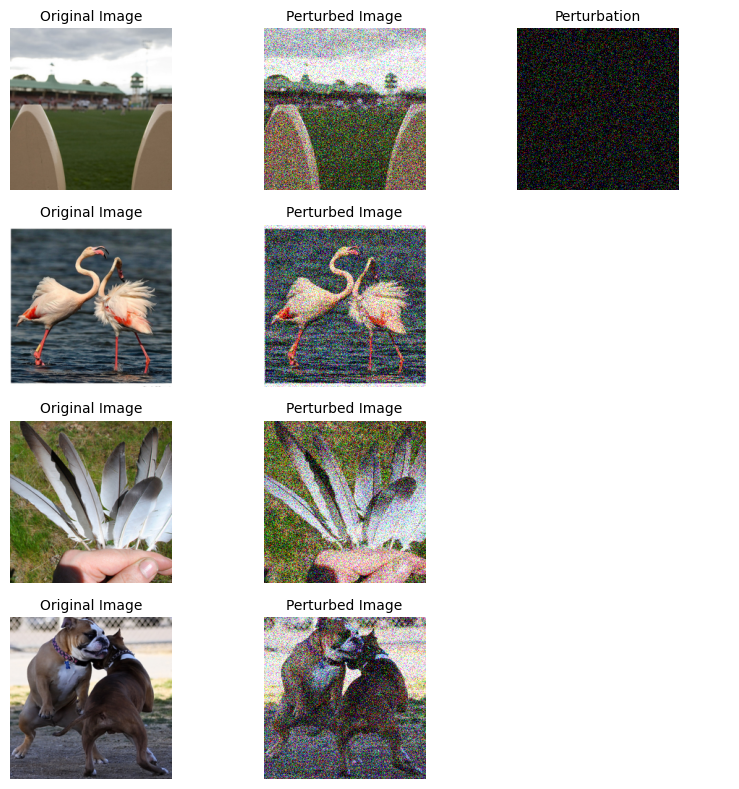


Generation 5 completed with fitness: [-1.25690231 -1.23909988 -1.24842072 -1.24751205 -1.26656876 -1.27327728
 -1.25570679 -1.24544373 -1.24604645 -1.22788086 -1.25802307 -1.24061661
 -1.28191071 -1.29525604 -1.28873444 -1.24602051 -1.25095139 -1.28007736
 -1.26385117 -1.22639694 -1.24738235 -1.26904297 -1.26366806 -1.26353836
 -1.21540146 -1.26013107 -1.23093109 -1.27498779 -1.25745773 -1.24338455
 -1.26219711 -1.26677551 -1.26929474 -1.31076431 -1.23836365 -1.22731171
 -1.22929077 -1.23484497 -1.25663986 -1.2467514 ]
Best Fitness = -1.2154014587402344

Best solution snippet: [ 0.          0.          0.          0.31070302 -0.31058127  0.22570735
  0.         -0.40663312  0.          0.44629687]
Best solution zeros count: 61448
Best perturbation magnitude: 85.74773406982422

Generation 6 completed with fitness: [-1.39812317 -1.45357971 -1.43736496 -1.44018707 -1.40797348 -1.43293991
 -1.47504578 -1.4492218  -1.44607391 -1.39902878 -1.4436882  -1.48709869
 -1.43478088 -1.44941177 -1.

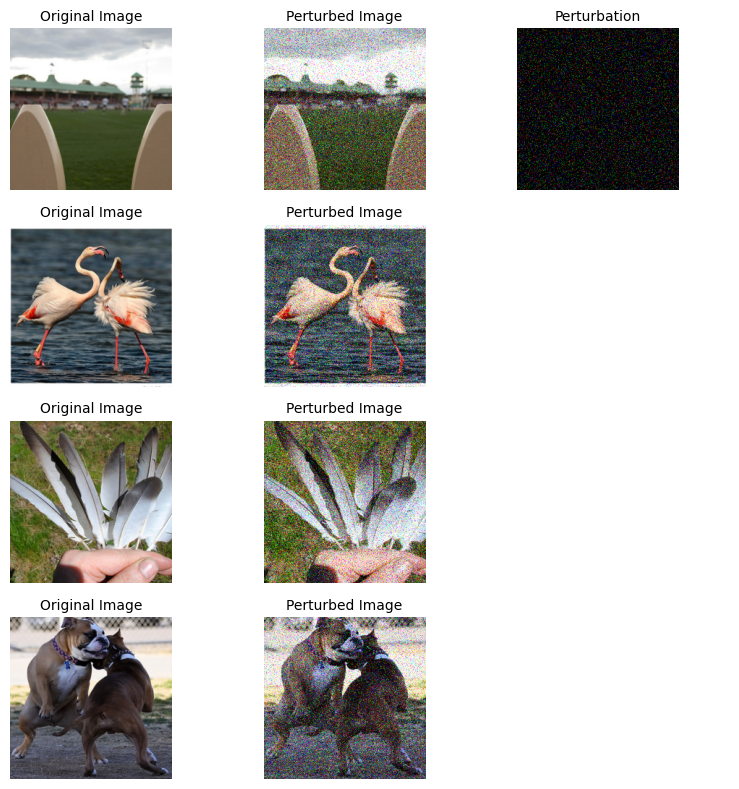

In [137]:
config = load_config()

ga_instance = pygad.GA(
    num_generations=config["ga"]["num_generations"],
    num_parents_mating=config["ga"]["num_parents_mating"],
    sol_per_pop=config["ga"]["sol_per_pop"],
    num_genes=3*224*224,
    gene_type=float,
    init_range_low=config["ga"]["init_range_low"],
    init_range_high=config["ga"]["init_range_high"],
    parent_selection_type=config["ga"]["parent_selection_type"],
    keep_elitism=config["ga"]["keep_elitism"],
    keep_parents=config["ga"]["keep_parents"],
    crossover_type=config["crossover"]["crossover_type"],
    crossover_probability=config["crossover"]["crossover_probability"],
    mutation_type=mutation_wrapper,
    # mutation_probability=config["ga"]["mutation_probability"],
    # mutation_percent_genes=config["ga"]["mutation_percent_genes"],
    fitness_func=fitness_wrapper,
    on_generation=on_generation,
    on_crossover=on_crossover,
)

ga_instance.run()

##### Best fitness records
- no pixel constraints: 0.84
- pixel constraint weight 1: 0.80
- above + max perturbation mag 100: 

In [138]:
input_batch.shape

torch.Size([64, 3, 224, 224])

In [139]:
# After the run
solution, solution_fitness, _ = ga_instance.best_solution()
print(f"Best solution fitness: {solution_fitness}") # Might be the penultimate best fitness??

Best solution fitness: -1.8121788024902346


# Calculating Universal Perturbation

torch.Size([3, 224, 224])
Universal perturbation created.


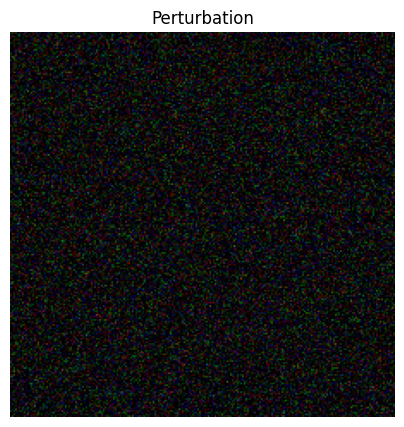

In [140]:
if len(top_perturbations) > 0:
    universal_perturbation = torch.mean(torch.stack(top_perturbations), dim=0)
    print(universal_perturbation.shape)
    print(f"Universal perturbation created.")
    visualize_perturbation(universal_perturbation)

# Metrics
(takes a while)

### GoogLeNet
(4 min)

In [155]:
evaluate_without_perturbation(model, dataloader, device)
# 0.6977

Using device: mps
Accuracy without perturbation: 0.69772


0.69772

In [ ]:
evaluate_with_perturbation(model, dataloader, universal_perturbation, device)
# 9/24: 0.37964
# 12/24: 0.39556

Using device: mps
Accuracy with perturbation: 0.39556


0.39556

### ViT b 16

In [ ]:
evaluate_without_perturbation(model, dataloader, device)
# 0.811
# 13 mins

Using device: cpu


RuntimeError: Mismatched Tensor types in NNPack convolutionOutput

In [ ]:
evaluate_with_perturbation(model, dataloader, universal_perturbation, device)